# IBM Professional Certification Program

## Sample Test

### Exam C1000-179

Fundamentals of Quantum Computing Using Qiskit v2.X Developer

[Link](https://www.ibm.com/training/certification/ibm-certified-quantum-computation-using-qiskit-v2x-developer-associate-C9008400)

## Section 3: Create quantum circuits

### 7. Given the code fragment below, which of the following code fragments creates a rotation gate with an angle with an initially undefined value?

```python
from qiskit.circuit import QuantumCircuit, Parameter, ParameterExpression

qc = QuantumCircuit(1)
```

a ( )
```python
theta = 3.14
qc.rx(3.14, 0)
```

b ( ) 
```python
theta = Parameter('theta')
qc.rx(theta, 0)
```

c ( )
```python
qc.rx('theta', 0)
```

d ( )
```python
qc.rx(ParameterExpression('theta'), 0)
```

### 8. Which one of the following types of register stores the result of a measured circuit? 

a ( ) Ancillary register

b ( ) Quantum register

c ( ) Classical register 

d ( ) Circuit register

### 9. Given the code fragment below, which one of the following images could be produced?

```python
from qiskit import QuantumCircuit
from qiskit import generate_preset_pass_manager

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

pass_manager = generate_preset_pass_manager(
    optimization_level=3,
    coupling_map=[[0, 1], [1, 2]],
    basis_gates=['h', 'swap', 'cx'],
    initial_layout=[0, 2]
)
tqc = pass_manager.run(qc)
tqc.draw(output="mpl")
```

a ( )

b ( )

c ( )

d ( )

## Quantum Teleportation

In [1]:
import numpy as np

from qiskit.circuit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.result import marginal_counts
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

In [2]:
simulator = AerSimulator(method="statevector")

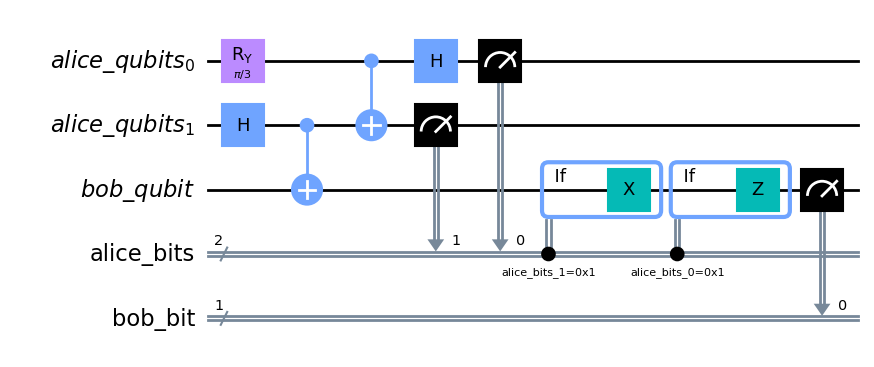

In [6]:
alice_bits = ClassicalRegister(size=2, name="alice_bits")
bob_bit = ClassicalRegister(size=1, name="bob_bit")

alice_qubits = QuantumRegister(size=2, name="alice_qubits")
bob_qubit = QuantumRegister(size=1, name="bob_qubit")

qc = QuantumCircuit(alice_qubits, bob_qubit, alice_bits, bob_bit)

qc.ry(theta=np.pi/3, qubit=alice_qubits[0])
qc.h(qubit=alice_qubits[1])
qc.cx(control_qubit=alice_qubits[1], target_qubit=bob_qubit)
qc.cx(control_qubit=alice_qubits[0], target_qubit=alice_qubits[1])
qc.h(qubit=alice_qubits[0])
qc.measure(qubit=alice_qubits, cbit=alice_bits)

with qc.if_test((alice_bits[1], 1)):
    qc.x(qubit=bob_qubit)
with qc.if_test((alice_bits[0], 1)):
    qc.z(qubit=bob_qubit)

qc.measure(qubit=bob_qubit, cbit=bob_bit)

qc.draw(output="mpl", style="clifford")

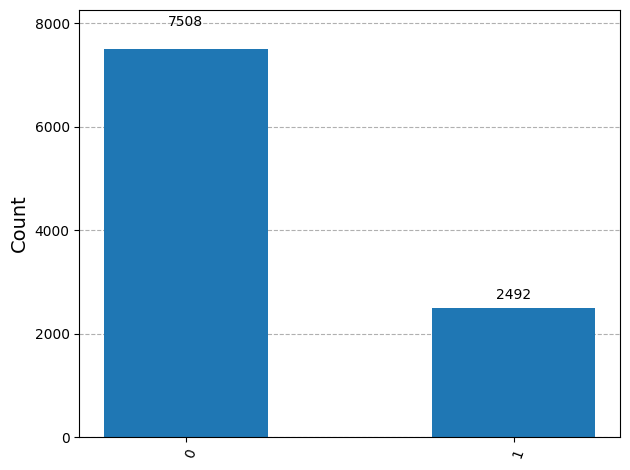

In [8]:
counts = simulator.run(circuits=qc, shots=10000).result().get_counts()
counts = marginal_counts(counts, [2])
plot_histogram(counts)